## Figures generated for University of Nebraska, Lincoln poster and CSU Research Competition.

This script implements a two-dimensional toggle-switch model for competing microglial phenotypes, classified based on the ratio of transcription factors STAT1 and STAT6, denoted $x_1$ and $x_2$, respectively.

Unlike classical models with fixed external inputs, the effective signals (cytokines) driving each state are state-dependent: each signal is enhanced by its own phenotype through a saturating Hill-type self-reinforcement term and suppressed by the opposing phenotype through a Hill-type cross-inhibition term. These effective signals modulate production via additional self-amplification and mutual inhibition factors.

The code analytically constructs the full vector field and its Jacobian, accounting for the dependence of the signals on both state variables. For each pair of baseline cytokine inputs, the system’s equilibria are computed from multiple initial guesses, filtered for linear stability using eigenvalue analysis, and classified as M1-dominant, M2-dominant, mixed, or bistable. Scanning across the cytokine input space yields a phase diagram that delineates regions of monostability, bistability, and mixed states, providing a compact visualization of how feedback strength and cross-suppression shape microglial phenotypic outcomes.

The goal of this code is to translate the results of the ODE single cell system into rules for phenotype selecting in a tissue-level agent-based model.  For M1, M2 and mixed phenotypes the rules are straightforward.  For bistable regions of signaling space, fate will depend on local agent history (hysteresis).  In the bistable region, the same local signal conditions can support either phenotype, so the outcome depends on the cell's history.

The equations being simulated are

\begin{aligned}
\frac{dx_1}{dt}
&=
S_1^{\mathrm{eff}}(x_1,x_2)
\left(1+\frac{a_1 x_1}{p_1+x_1}\right)
\left(\frac{c_1}{c_1+S_2^{\mathrm{eff}}(x_1,x_2)}\right)
+
b_1
-
q_1 x_1
\\[8pt]
\frac{dx_2}{dt}
&=
S_2^{\mathrm{eff}}(x_1,x_2)
\left(1+\frac{a_2 x_2}{p_2+x_2}\right)
\left(\frac{c_2}{c_2+S_1^{\mathrm{eff}}(x_1,x_2)}\right)
+
b_2
-
q_2 x_2
\end{aligned}


\begin{aligned}
S_1^{\mathrm{eff}}(x_1,x_2)
&=
S_{1,0}
+
k_1
\frac{x_1^{n_{s1}}}{K_{s1}^{n_{s1}} + x_1^{n_{s1}}}
\frac{K_{12}^{n_{12}}}{K_{12}^{n_{12}} + x_2^{n_{12}}}
\\[8pt]
S_2^{\mathrm{eff}}(x_1,x_2)
&=
S_{2,0}
+
k_2
\frac{x_2^{n_{s2}}}{K_{s2}^{n_{s2}} + x_2^{n_{s2}}}
\frac{K_{21}^{n_{21}}}{K_{21}^{n_{21}} + x_1^{n_{21}}}
\end{aligned}




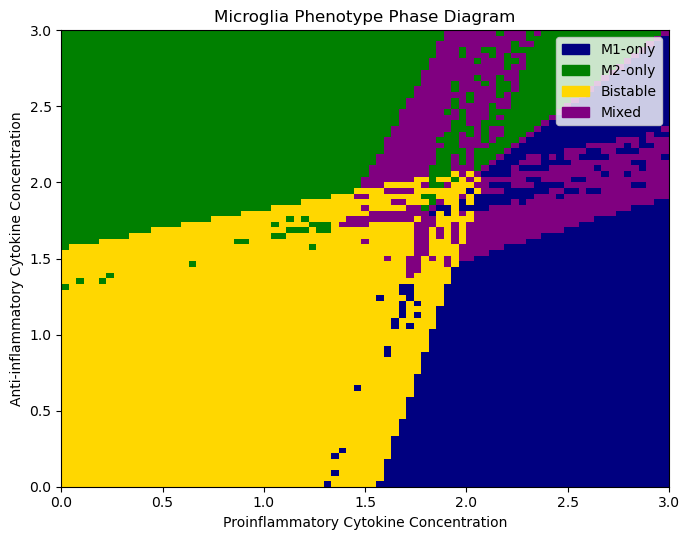

In [ ]:
# ============================================================
# 2D microglia toggle model with STATE-DEPENDENT signals S1,S2
# (Hill self-signal + cross-suppression)
#
# Base model:
# dx1/dt = Seff1 * (1 + a1*x1/(p1 + x1)) * (c1/(c1 + Seff2)) + b1 - q1*x1
# dx2/dt = Seff2 * (1 + a2*x2/(p2 + x2)) * (c2/(c2 + Seff1)) + b2 - q2*x2
#
# Seff1 = S1_base + k1 * Hill_inc(x1;Ks1,ns1) * Hill_dec(x2;K12,n12)
# Seff2 = S2_base + k2 * Hill_inc(x2;Ks2,ns2) * Hill_dec(x1;K21,n21)
#
# Colors:
#   M1-only      -> dark blue
#   M2-only      -> green
#   Bistable     -> yellow
#   Mixed        -> purple
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.optimize import root

# ------------------------------------------------------------
# Hill functions + derivatives
# ------------------------------------------------------------
def pos(x):
    return max(0.0, float(x))

def hill_inc(s, K=1.0, n=4):
    s = pos(s)
    return (s**n) / (K**n + s**n) if (K**n + s**n) > 0 else 0.0

def hill_dec(s, K=1.0, n=4):
    s = pos(s)
    return (K**n) / (K**n + s**n) if (K**n + s**n) > 0 else 1.0

def dhill_inc_ds(s, K=1.0, n=4):
    s = pos(s)
    denom = (K**n + s**n)
    if denom <= 0 or s == 0:
        return 0.0
    # d/ds [ s^n/(K^n + s^n) ] = n*K^n*s^(n-1) / (K^n + s^n)^2
    return n * (K**n) * (s**(n-1)) / (denom**2)

def dhill_dec_ds(s, K=1.0, n=4):
    # hill_dec = 1 - hill_inc
    return -dhill_inc_ds(s, K, n)

# ------------------------------------------------------------
# Saturating self-amplification term and derivative
# ------------------------------------------------------------
def self_amp(x, a, p):
    x = pos(x)
    return 1.0 + (a * x) / (p + x) if (p + x) > 0 else 1.0

def d_self_amp_dx(x, a, p):
    x = pos(x)
    denom = (p + x)
    if denom <= 0:
        return 0.0
    # d/dx [a*x/(p+x)] = a*p/(p+x)^2
    return a * p / (denom**2)

# ------------------------------------------------------------
# Inhibition c/(c + S) and derivative wrt S
# ------------------------------------------------------------
def inhib(S_other, c):
    S_other = pos(S_other)
    return c / (c + S_other) if (c + S_other) > 0 else 0.0

def dinhib_dS(S_other, c):
    S_other = pos(S_other)
    denom = (c + S_other)
    if denom <= 0:
        return 0.0
    # d/dS [ c/(c+S) ] = -c/(c+S)^2
    return -c / (denom**2)

# ------------------------------------------------------------
# State-dependent signals
# ------------------------------------------------------------
def Seff1(x1, x2, S1_base, pars):
    return (S1_base
            + pars["k1"] * hill_inc(x1, pars["Ks1"], pars["ns1"]) * hill_dec(x2, pars["K12"], pars["n12"]))

def Seff2(x1, x2, S2_base, pars):
    return (S2_base
            + pars["k2"] * hill_inc(x2, pars["Ks2"], pars["ns2"]) * hill_dec(x1, pars["K21"], pars["n21"]))

def dSeff1_dx1(x1, x2, pars):
    return pars["k1"] * dhill_inc_ds(x1, pars["Ks1"], pars["ns1"]) * hill_dec(x2, pars["K12"], pars["n12"])

def dSeff1_dx2(x1, x2, pars):
    return pars["k1"] * hill_inc(x1, pars["Ks1"], pars["ns1"]) * dhill_dec_ds(x2, pars["K12"], pars["n12"])

def dSeff2_dx2(x1, x2, pars):
    return pars["k2"] * dhill_inc_ds(x2, pars["Ks2"], pars["ns2"]) * hill_dec(x1, pars["K21"], pars["n21"])

def dSeff2_dx1(x1, x2, pars):
    return pars["k2"] * hill_inc(x2, pars["Ks2"], pars["ns2"]) * dhill_dec_ds(x1, pars["K21"], pars["n21"])

# ------------------------------------------------------------
# Vector field
# ------------------------------------------------------------
def f_vec(x1, x2, S1_base, S2_base, pars):
    a1, p1, c1, b1, q1 = pars["a1"], pars["p1"], pars["c1"], pars["b1"], pars["q1"]
    a2, p2, c2, b2, q2 = pars["a2"], pars["p2"], pars["c2"], pars["b2"], pars["q2"]

    x1p, x2p = pos(x1), pos(x2)

    S1e = Seff1(x1p, x2p, S1_base, pars)
    S2e = Seff2(x1p, x2p, S2_base, pars)

    g1 = self_amp(x1p, a1, p1)
    g2 = self_amp(x2p, a2, p2)

    h1 = inhib(S2e, c1)   # S2 inhibits x1 production
    h2 = inhib(S1e, c2)   # S1 inhibits x2 production

    dx1 = S1e * g1 * h1 + b1 - q1 * x1p
    dx2 = S2e * g2 * h2 + b2 - q2 * x2p
    return np.array([dx1, dx2], dtype=float)

def F(z, S1_base, S2_base, pars):
    x1, x2 = z
    return f_vec(x1, x2, S1_base, S2_base, pars)

# ------------------------------------------------------------
# Jacobian 
# ------------------------------------------------------------
def jacobian(x1, x2, S1_base, S2_base, pars):
    a1, p1, c1, q1 = pars["a1"], pars["p1"], pars["c1"], pars["q1"]
    a2, p2, c2, q2 = pars["a2"], pars["p2"], pars["c2"], pars["q2"]

    x1p, x2p = pos(x1), pos(x2)

    S1e = Seff1(x1p, x2p, S1_base, pars)
    S2e = Seff2(x1p, x2p, S2_base, pars)

    g1 = self_amp(x1p, a1, p1)
    g2 = self_amp(x2p, a2, p2)

    dg1 = d_self_amp_dx(x1p, a1, p1)
    dg2 = d_self_amp_dx(x2p, a2, p2)

    h1 = inhib(S2e, c1)
    h2 = inhib(S1e, c2)

    dh1_dS2e = dinhib_dS(S2e, c1)
    dh2_dS1e = dinhib_dS(S1e, c2)

    dS1_dx1 = dSeff1_dx1(x1p, x2p, pars)
    dS1_dx2 = dSeff1_dx2(x1p, x2p, pars)
    dS2_dx1 = dSeff2_dx1(x1p, x2p, pars)
    dS2_dx2 = dSeff2_dx2(x1p, x2p, pars)

    # dx1 = S1e*g1*h1 + b1 - q1*x1, take partial wrt x1
    J11 = dS1_dx1 * g1 * h1 + S1e * dg1 * h1 + S1e * g1 * dh1_dS2e * dS2_dx1 - q1

    # take partial wrt x2
    J12 = dS1_dx2 * g1 * h1 + S1e * g1 * dh1_dS2e * dS2_dx2

    # dx2 = S2e*g2*h2 + b2 - q2*x2
    # take partial wrt x1
    J21 = dS2_dx1 * g2 * h2 + S2e * g2 * dh2_dS1e * dS1_dx1

    # take partial wrt x2
    J22 = dS2_dx2 * g2 * h2 + S2e * dg2 * h2 + S2e * g2 * dh2_dS1e * dS1_dx2 - q2

    return np.array([[J11, J12],
                     [J21, J22]], dtype=float)

def is_stable(x1, x2, S1_base, S2_base, pars):
    eigvals = np.linalg.eigvals(jacobian(x1, x2, S1_base, S2_base, pars))
    return np.all(np.real(eigvals) < 0)

# ------------------------------------------------------------
# Equilibrium finding
# ------------------------------------------------------------
def solve_equilibrium(S1_base, S2_base, pars, guess):
    sol = root(lambda z: F(z, S1_base, S2_base, pars), guess)
    if not sol.success:
        return None
    x1, x2 = sol.x
    return pos(x1), pos(x2)

def cluster(points, tol=1e-4):
    uniq = []
    for p in points:
        if not any(np.linalg.norm(np.array(p) - np.array(q)) < tol for q in uniq):
            uniq.append(p)
    return uniq

def stable_equilibria(S1_base, S2_base, pars, guesses):
    sols = []
    for g in guesses:
        p = solve_equilibrium(S1_base, S2_base, pars, g)
        if p is not None and is_stable(p[0], p[1], S1_base, S2_base, pars):
            sols.append(p)
    return cluster(sols)

# ------------------------------------------------------------
# Phenotype labeling
# theta is our threshold -- if x1 and x2 are within theta of each other, mixed 
# ------------------------------------------------------------
def phenotype(x1, x2, theta=0.05):
    if x1 - x2 > theta:
        return "M1"
    elif x2 - x1 > theta:
        return "M2"
    else:
        return "Mixed"

# ------------------------------------------------------------
# Phase diagram
# ------------------------------------------------------------
def phase_diagram(S1_vals, S2_vals, pars, theta=0.05):
    region = np.zeros((len(S1_vals), len(S2_vals)), dtype=int)

    guesses = [
        (0, 0), (0, 1), (1, 0), (1, 1),
        (0, 5), (5, 0), (5, 5),
        (0,10), (10,0), (10,10),
        (0,20), (20,0), (20,20)
    ]

    for i, S1b in enumerate(S1_vals):
        for j, S2b in enumerate(S2_vals):
            stables = stable_equilibria(S1b, S2b, pars, guesses)
            labels = [phenotype(x1, x2, theta) for x1, x2 in stables]

            if len(stables) == 1:
                region[i, j] = 1 if labels[0] == "M1" else 2 if labels[0] == "M2" else 4
            elif len(stables) >= 2 and ("M1" in labels) and ("M2" in labels):
                region[i, j] = 3
            elif len(stables) >= 1:
                region[i, j] = 4

    return region

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
def plot_phase_diagram(S1_vals, S2_vals, region):
    colors = ["white", "navy", "green", "gold", "purple"]
    cmap = ListedColormap(colors)

    plt.figure(figsize=(7, 5.5))
    plt.imshow(region.T, origin="lower",
               extent=[S1_vals[0], S1_vals[-1], S2_vals[0], S2_vals[-1]],
               cmap=cmap, vmin=0, vmax=4, aspect="auto")

    plt.xlabel("Proinflammatory Cytokine Concentration")
    plt.ylabel("Anti-inflammatory Cytokine Concentration")
    plt.title("Microglia Phenotype Phase Diagram")

    legend = [
        mpatches.Patch(color="navy", label="M1-only"),
        mpatches.Patch(color="green", label="M2-only"),
        mpatches.Patch(color="gold", label="Bistable"),
        mpatches.Patch(color="purple", label="Mixed"),
    ]
    plt.legend(handles=legend, loc="upper right", frameon=True)
    plt.tight_layout()
    # save figure
    plt.savefig("microglia_phase_diagram.png", dpi=300, bbox_inches="tight")

    plt.show()

# ============================================================
# RUN (starter parameters that often yield bistability)
# Later iterations will set these from the biological literature
# ============================================================
pars = dict(
    # kinetics
    a1=4.0,  p1=1.0,  c1=1.0,  b1=0.05, q1=1.0,
    a2=4.0,  p2=1.0,  c2=1.0,  b2=0.05, q2=1.0,

    # signal feedback parameters
    k1=6.0,  Ks1=1.0, ns1=6,   # x1 -> S1 boost
    k2=6.0,  Ks2=1.0, ns2=6,   # x2 -> S2 boost

    # cross-suppression of signal production
    K12=1.0, n12=6,            # x2 suppresses S1 production
    K21=1.0, n21=6             # x1 suppresses S2 production
)

S1_vals = np.linspace(0, 3, 81)
S2_vals = np.linspace(0, 3, 81)

region = phase_diagram(S1_vals, S2_vals, pars, theta=0.05)
plot_phase_diagram(S1_vals, S2_vals, region)


### Agent-based Model Figures
This agent-based model (ABM) simulates the neuroimmune response in brain tissue, focusing on interactions between neurons, microglia (immune cells), and astrocytes (support cells). The model tracks how neurons transition between healthy, damaged, and dead states in response to inflammatory signals, while microglia dynamically shift between pro-inflammatory (M1), anti-inflammatory (M2), and homeostatic (M0) phenotypes based on local cytokine conditions. Astrocytes similarly transition between A0, A1, and A2 states, modulating inflammation and supporting neuronal recovery. 

A key feature is the lipid droplet (LD) metabolism system: damaged neurons produce lipids that can be transferred to astrocytes for oxidation into anti-inflammatory signals, while microglia accumulate lipids through phagocytosis, which can trigger hyperinflammation when lipid burden exceeds certain thresholds. The model captures the balance between tissue damage and repair, allowing exploration of how parameters like cytokine decay rates, phagocytic efficiency, astrocyte coverage, and lipid-driven amplification affect inflammation resolution versus chronicity.

This ABM is based on the lab's previous work (see citations below).  The model was translated from NetLogo to Mesa, and students added astrocytes as agents, and pathways for lipid transport during the 2025-2026 academic year.


In [ ]:
from __future__ import annotations

import numpy as np
from mesa import Agent, Model
from mesa.space import MultiGrid
from mesa.datacollection import DataCollector


# ============================================================
# Utilities
# ============================================================
def pos(x: float) -> float:
    """Clamp to nonnegative float."""
    return max(0.0, float(x))


def safe_ratio(num: float, den: float, eps: float = 1e-9) -> float:
    return float(num) / (float(den) + eps)


# ============================================================
# Agents
# ============================================================
class Neuron(Agent):
    def __init__(
        self,
        unique_id,
        model,
        damaged: bool = False,
        dead: bool = False,
        healthy: bool = True,
        reach: int = 2,
        ticks_damaged: int = 0,
    ):
        super().__init__(unique_id, model)
        self.pos = None

        self.dead = bool(dead)
        self.damaged = bool(damaged) and not self.dead
        self.healthy = bool(healthy) and (not self.damaged) and (not self.dead)

        self.reach = int(reach)
        self.ticks_damaged = int(ticks_damaged)

        self.lipid_droplets = 0.0

        if self.damaged:
            self.healthy = False
        if self.dead:
            self.healthy = False
            self.damaged = False

    # ---- state transitions ----
    def become_damaged(self):
        if self.pos is None or self.dead or self.damaged:
            return
        self.healthy = False
        self.damaged = True
        self.ticks_damaged = 0
        self.reach = 1

        x, y = self.pos
        self.model._mark_residence(x, y, damage=1.0, pro=1.0)
        self.lipid_droplets = min(
            self.lipid_droplets + self.model.neuron_ld_damage_boost,
            self.model.neuron_ld_max,
        )

    def become_dead(self):
        if self.pos is None or self.dead:
            return
        self.dead = True
        self.damaged = False
        self.healthy = False
        self.ticks_damaged = 0
        self.reach = 0

        x, y = self.pos
        self.model._mark_residence(x, y, damage=1.5, pro=1.0)
        self.lipid_droplets = min(
            self.lipid_droplets + self.model.neuron_ld_death_boost,
            self.model.neuron_ld_max,
        )

    def become_healthy(self):
        if self.pos is None or self.dead or self.healthy:
            return
        self.damaged = False
        self.healthy = True
        self.ticks_damaged = 0
        self.reach = 2
        self.lipid_droplets *= 0.2

    # ---- lipid export ----
    def _maybe_export_lipids_to_astrocytes(self):
        if self.pos is None or self.lipid_droplets <= 0.0:
            return

        x, y = self.pos
        neigh = self.model.grid.get_neighborhood(
            (x, y),
            moore=True,
            include_center=True,
            radius=self.model.neuron_to_astro_ld_transfer_radius,
        )
        cells = self.model.grid.get_cell_list_contents(neigh)
        astrocytes = [a for a in cells if isinstance(a, Astrocyte)]
        if not astrocytes:
            return

        if self.model.random.random() < self.model.neuron_to_astro_ld_transfer_prob:
            target = self.model.random.choice(astrocytes)
            packet = min(self.lipid_droplets, self.model.neuron_ld_packet_size)
            if packet > 0:
                self.lipid_droplets -= packet
                target.lipid_pool += packet

    def step(self):
        if self.pos is None or self.dead:
            return

        x, y = self.pos
        neigh = self.model.grid.get_neighborhood((x, y), moore=True, include_center=False, radius=1)
        if not neigh:
            return

        mean_pro = float(np.mean([self.model.pro_inflam_val[nx, ny] for nx, ny in neigh]))
        mean_anti = float(np.mean([self.model.anti_inflam_val[nx, ny] for nx, ny in neigh]))
        ratio = safe_ratio(mean_pro, mean_anti)

        # Healthy -> damaged
        if self.healthy and ratio >= self.model.damage_ratio_thresh:
            if self.model.random.random() < self.model.damage_chance:
                self.become_damaged()
            return

        if not self.damaged:
            return

        # Damaged progression
        self.ticks_damaged += 1
        self.lipid_droplets = min(
            self.lipid_droplets + self.model.neuron_ld_production_rate,
            self.model.neuron_ld_max,
        )
        self._maybe_export_lipids_to_astrocytes()

        # Damaged -> dead
        if self.ticks_damaged >= self.model.damage_to_death_ticks:
            if ratio >= self.model.death_ratio_thresh and self.model.random.random() < self.model.death_chance:
                self.become_dead()
                return

        # Damaged -> healthy (resolution)
        if ratio <= self.model.healthy_ratio_thresh and self.model.random.random() < self.model.healthy_chance:
            self.become_healthy()


class Astrocyte(Agent):
    def __init__(self, unique_id, model, phenotype: str = "A0"):
        super().__init__(unique_id, model)
        self.pos = None
        self.phenotype = phenotype  # "A0", "A1", "A2"
        self.coverage_radius = self.model.astro_coverage_radius
        self.resolution_ticks = 0
        self.lipid_pool = 1.0

    def _positions_in_radius(self):
        x, y = self.pos
        return self.model.grid.get_neighborhood((x, y), moore=True, include_center=True, radius=self.coverage_radius)

    def _nearby_microglia_counts(self):
        cells = self.model.grid.get_cell_list_contents(self._positions_in_radius())
        m1 = sum(1 for a in cells if isinstance(a, Microglia) and a.phenotype == "M1")
        m2 = sum(1 for a in cells if isinstance(a, Microglia) and a.phenotype == "M2")
        return m1, m2

    def _oxidize_lipids(self):
        if self.pos is None or self.lipid_pool <= 0.0:
            return
        x, y = self.pos
        total = float(self.model.pro_inflam_val[x, y] + self.model.anti_inflam_val[x, y])
        if total < self.model.astro_homeo_signal_thresh:
            return

        frac = max(0.0, min(1.0, float(self.model.astro_ld_oxidation_rate)))
        used = self.lipid_pool * frac
        if used <= 0.0:
            return

        self.lipid_pool -= used
        self.model.anti_inflam_val[x, y] += used * self.model.astro_ld_to_anti_inflam

    def _update_phenotype(self):
        x, y = self.pos
        pro = float(self.model.pro_inflam_val[x, y])
        anti = float(self.model.anti_inflam_val[x, y])
        total = pro + anti

        # neighbor bias (optional “crosstalk”)
        m1, m2 = self._nearby_microglia_counts()
        r = self.model.random.random()
        if m1 > 0 and r < 0.3:
            self.phenotype = "A1"
        elif m2 > 0 and r < 0.3:
            self.phenotype = "A2"
        else:
            if total < self.model.astro_homeo_signal_thresh:
                if self.model.random.random() < self.model.astro_homeo_chance:
                    self.phenotype = "A0"
            else:
                ratio = safe_ratio(pro, anti)
                r2 = self.model.random.random()
                if ratio >= self.model.astro_pro_inflam_signal_thresh:
                    if r2 < self.model.astro_pro_inflam_chance:
                        self.phenotype = "A1"
                elif ratio <= self.model.astro_anti_inflam_signal_thresh:
                    if r2 < self.model.astro_anti_inflam_chance:
                        self.phenotype = "A2"
                else:
                    if r2 < self.model.astro_homeo_chance:
                        self.phenotype = "A0"

        # A2 resolves back to A0 after quiet period
        if self.phenotype == "A2" and total < self.model.astro_homeo_signal_thresh:
            self.resolution_ticks += 1
            if self.resolution_ticks >= self.model.a2_to_a0_resolution_ticks:
                self.phenotype = "A0"
                self.resolution_ticks = 0
        else:
            self.resolution_ticks = 0

    def _modulate_fields(self):
        for nx, ny in self._positions_in_radius():
            if self.phenotype == "A1":
                self.model.pro_inflam_val[nx, ny] += 0.15
            elif self.phenotype == "A2":
                self.model.anti_inflam_val[nx, ny] += 0.15
                self.model.pro_inflam_val[nx, ny] = max(0.0, self.model.pro_inflam_val[nx, ny] - 0.07)
            else:
                self.model.pro_inflam_val[nx, ny] *= 0.99

    def _act_on_neurons(self):
        cells = self.model.grid.get_cell_list_contents(self._positions_in_radius())
        neurons = [a for a in cells if isinstance(a, Neuron)]
        if not neurons:
            return

        if self.phenotype == "A2":
            # healing + damage reduction
            for neuron in neurons:
                if neuron.damaged and not neuron.dead:
                    base_p = 0.2
                    lipid_boost = min(self.lipid_pool * 0.01, 0.3)
                    p_heal = min(1.0, base_p + lipid_boost)
                    if self.model.random.random() < p_heal:
                        neuron.become_healthy()
            for nx, ny in self._positions_in_radius():
                self.model.damage_val[nx, ny] = max(0.0, self.model.damage_val[nx, ny] - 0.1)

        elif self.phenotype == "A1":
            # injurious environment
            for neuron in neurons:
                if neuron.healthy and self.model.random.random() < 0.01:
                    neuron.become_damaged()
                elif neuron.damaged and not neuron.dead and self.model.random.random() < 0.05:
                    neuron.become_dead()

        else:
            # weak homeostatic support
            for neuron in neurons:
                if neuron.damaged and not neuron.dead and self.model.random.random() < 0.02:
                    neuron.become_healthy()

    def _maybe_recruit_microglia(self):
        if self.phenotype != "A1" or self.pos is None:
            return
        x, y = self.pos
        local = float(self.model.damage_val[x, y] + self.model.pro_inflam_val[x, y])
        if local < self.model.recruitment_threshold:
            return
        if self.model.random.random() < self.model.microglia_recruitment_prob:
            m = Microglia(self.model.next_id(), self.model, phenotype="M1")
            self.model.grid.place_agent(m, (x, y))
            self.model.microglia.append(m)

    def step(self):
        if self.pos is None:
            return
        self._update_phenotype()
        self._oxidize_lipids()
        self._modulate_fields()
        self._act_on_neurons()
        self._maybe_recruit_microglia()


class Microglia(Agent):
    def __init__(self, unique_id, model, phenotype: str):
        super().__init__(unique_id, model)
        self.pos = None
        self.phenotype = phenotype  # "M0", "M1", "M2"
        self.wait_ticks = 0
        self.resolution_ticks = 0
        self.lipid_droplets = 0.0

    # ---- phenotype logic ----
    def _update_phenotype(self):
        x, y = self.pos
        pro = float(self.model.pro_inflam_val[x, y])
        anti = float(self.model.anti_inflam_val[x, y])
        total = pro + anti

        if total < self.model.homeo_signal_thresh:
            if self.model.random.random() < self.model.homeo_chance:
                self.phenotype = "M0"
        else:
            ratio = safe_ratio(pro, anti)
            r = self.model.random.random()
            if ratio >= self.model.pro_inflam_signal_thresh:
                if r < self.model.pro_inflam_chance:
                    self.phenotype = "M1"
            elif ratio <= self.model.anti_inflam_signal_thresh:
                if r < self.model.anti_inflam_chance:
                    self.phenotype = "M2"
            else:
                if r < self.model.homeo_chance:
                    self.phenotype = "M0"

        # M2 resolves back to M0 after quiet period
        if self.phenotype == "M2" and total < self.model.homeo_signal_thresh:
            self.resolution_ticks += 1
            if self.resolution_ticks >= self.model.m2_to_m0_resolution_ticks:
                self.phenotype = "M0"
                self.resolution_ticks = 0
        else:
            self.resolution_ticks = 0

    # ---- movement ----
    def _random_step(self):
        neighbors = self.model.grid.get_neighborhood(self.pos, moore=True, include_center=False)
        if neighbors:
            self.model.grid.move_agent(self, self.model.random.choice(neighbors))

    def _chemotaxis_step(self, field: np.ndarray):
        neighbors = self.model.grid.get_neighborhood(self.pos, moore=True, include_center=False)
        if not neighbors:
            return
        vals = [(p, field[p[0], p[1]]) for p in neighbors]
        max_val = max(v for _, v in vals)
        best = [p for p, v in vals if v == max_val]
        self.model.grid.move_agent(self, self.model.random.choice(best))

    def _move(self):
        # M1/M2 bias toward damage; M0 random
        if self.phenotype == "M0":
            self._random_step()
            return
        if self.model.random.random() < self.model.sensing_efficiency:
            self._chemotaxis_step(self.model.damage_val)
        else:
            self._random_step()

    # ---- interactions ----
    def _neurons_here(self):
        return [a for a in self.model.grid.get_cell_list_contents([self.pos]) if isinstance(a, Neuron)]

    def _eat_neuron(self, neuron: Neuron, cytokine: str, amount: float, ld_gain: float = 0.0):
        # remove neuron
        self.model.remove_neuron(neuron)
        x, y = self.pos
        if cytokine == "pro":
            self.model.pro_inflam_val[x, y] += amount
        else:
            self.model.anti_inflam_val[x, y] += amount
        if ld_gain > 0:
            self.lipid_droplets = min(self.lipid_droplets + ld_gain, self.model.microglia_ld_max)

    def _interact(self) -> bool:
        neurons = self._neurons_here()
        if not neurons:
            return False

        for neuron in neurons:
            if neuron.pos is None:
                continue

            if self.phenotype == "M0":
                # phagocytose dead neurons (weak)
                if neuron.dead and self.model.random.random() < self.model.eat_probability:
                    self._eat_neuron(neuron, cytokine="anti", amount=0.05)
                self.wait_ticks = 5
                return True

            if self.phenotype == "M1":
                # aggressive phagocytosis of damaged/dead neurons
                if (neuron.damaged or neuron.dead):
                    p = min(1.0, self.model.eat_probability * 1.2)
                    if self.model.random.random() < p:
                        ld_from_neuron = float(getattr(neuron, "lipid_droplets", 0.0))
                        ld_gain = ld_from_neuron + self.model.microglia_ld_from_phagocytosis
                        self._eat_neuron(neuron, cytokine="pro", amount=1.0, ld_gain=ld_gain)
                    self.wait_ticks = 5
                    return True

            if self.phenotype == "M2":
                # clears dead neurons and can heal damaged ones
                if neuron.dead:
                    if self.model.random.random() < self.model.eat_probability:
                        ld_from_neuron = float(getattr(neuron, "lipid_droplets", 0.0))
                        ld_gain = ld_from_neuron + self.model.microglia_ld_from_phagocytosis
                        self._eat_neuron(neuron, cytokine="anti", amount=1.0, ld_gain=ld_gain)
                        x, y = self.pos
                        self.model.dismantling[x, y] = True
                        self.model.dis_curr[x, y] = self.model.damage_radius
                    self.wait_ticks = 5
                    return True

                if neuron.damaged and (not neuron.dead):
                    if self.model.random.random() < self.model.sensing_efficiency:
                        neuron.become_healthy()
                        x, y = self.pos
                        self.model.anti_inflam_val[x, y] += 1.0
                        self.model.pro_inflam_val[x, y] = max(0.0, self.model.pro_inflam_val[x, y] - 1.0)
                    self.wait_ticks = 5
                    return True

        return False

    def _emit_cytokines(self):
        if self.pos is None:
            return
        neigh = self.model.grid.get_neighborhood(self.pos, moore=True, include_center=True)

        if self.phenotype == "M1":
            ld_factor = 1.0
            if self.lipid_droplets >= self.model.microglia_ld_pro_inflam_threshold:
                ld_factor += self.model.microglia_ld_pro_inflam_boost
            for nx, ny in neigh:
                self.model.pro_inflam_val[nx, ny] += 0.2 * ld_factor

        elif self.phenotype == "M2":
            for nx, ny in neigh:
                self.model.anti_inflam_val[nx, ny] += 0.2

    def step(self):
        if self.pos is None:
            return
        if self.wait_ticks > 0:
            self.wait_ticks -= 1
            return

        self._update_phenotype()

        # NOTE: your original code had temperature baked in (72-37). Kept same behavior:
        base_speed = max(0.0, 1.0 + 0.05 * (72 - 37.0))
        speed_factor = 1.5 if self.phenotype == "M1" else 1.0
        speed = base_speed * speed_factor

        moves = 1
        extra = speed - 1.0
        if extra > 0 and self.model.random.random() < extra:
            moves += 1

        for _ in range(moves):
            self._move()
            acted = self._interact()
            self._emit_cytokines()
            if acted:
                break


# ============================================================
# Model
# ============================================================
class MicrogliaNeuronModel(Model):
    def __init__(
        self,
        width: int = 33,
        height: int = 33,
        torus: bool = True,
        init_m0_microglia: int = 5,
        init_m1_microglia: int = 5,
        init_m2_microglia: int = 5,
        init_healthy_neuron: int = 10,
        init_damaged_neuron: int = 10,
        init_dead_neuron: int = 10,
        init_a0_astrocytes: int = 10,
        init_a1_astrocytes: int = 5,
        init_a2_astrocytes: int = 5,
        astro_coverage_radius: int = 2,
        eat_probability: float = 0.70,
        sensing_efficiency: float = 0.50,
        damage_chance: float = 0.005,
        neuron_distance: int = 5,
        damage_radius: int = 3,
        seed: int | None = None,
        damage_ratio_thresh: float = 0.6,
        healthy_ratio_thresh: float = 0.2,
        healthy_chance: float = 0.20,
        damage_to_death_ticks: int = 20,
        death_ratio_thresh: float = 0.9,
        death_chance: float = 0.25,
        homeo_signal_thresh: float = 1.0,
        pro_inflam_signal_thresh: float = 0.2,
        anti_inflam_signal_thresh: float = 0.8,
        homeo_chance: float = 0.2,
        pro_inflam_chance: float = 0.2,
        anti_inflam_chance: float = 0.2,
        astro_homeo_signal_thresh: float = 0.5,
        astro_pro_inflam_signal_thresh: float = 0.15,
        astro_anti_inflam_signal_thresh: float = 0.6,
        astro_homeo_chance: float = 0.25,
        astro_pro_inflam_chance: float = 0.3,
        astro_anti_inflam_chance: float = 0.3,
        pro_decay: float = 0.20,
        anti_decay: float = 0.10,
        m2_to_m0_resolution_ticks: int = 10,
        a2_to_a0_resolution_ticks: int = 15,
        recruitment_threshold: float = 3.0,
        microglia_recruitment_prob: float = 0.01,
        neuron_ld_production_rate: float = 0.2,
        neuron_ld_damage_boost: float = 0.5,
        neuron_ld_death_boost: float = 1.0,
        neuron_ld_packet_size: float = 0.5,
        neuron_to_astro_ld_transfer_prob: float = 0.3,
        neuron_to_astro_ld_transfer_radius: int = 2,
        astro_ld_oxidation_rate: float = 0.05,
        astro_ld_to_anti_inflam: float = 0.05,
        microglia_ld_from_phagocytosis: float = 0.5,
        microglia_ld_pro_inflam_threshold: float = 5.0,
        microglia_ld_pro_inflam_boost: float = 0.5,
    ):
        super().__init__(seed=seed)

        self.grid = MultiGrid(width, height, torus=torus)
        self.width, self.height = int(width), int(height)
        self.damage_radius = int(damage_radius)

        # core params
        self.eat_probability = float(eat_probability)
        self.sensing_efficiency = float(sensing_efficiency)
        self.damage_chance = float(damage_chance)
        self.damage_ratio_thresh = float(damage_ratio_thresh)
        self.healthy_ratio_thresh = float(healthy_ratio_thresh)
        self.healthy_chance = float(healthy_chance)
        self.damage_to_death_ticks = int(damage_to_death_ticks)
        self.death_ratio_thresh = float(death_ratio_thresh)
        self.death_chance = float(death_chance)

        # phenotype thresholds
        self.homeo_signal_thresh = float(homeo_signal_thresh)
        self.pro_inflam_signal_thresh = float(pro_inflam_signal_thresh)
        self.anti_inflam_signal_thresh = float(anti_inflam_signal_thresh)
        self.homeo_chance = float(homeo_chance)
        self.pro_inflam_chance = float(pro_inflam_chance)
        self.anti_inflam_chance = float(anti_inflam_chance)

        # astro thresholds
        self.astro_homeo_signal_thresh = float(astro_homeo_signal_thresh)
        self.astro_pro_inflam_signal_thresh = float(astro_pro_inflam_signal_thresh)
        self.astro_anti_inflam_signal_thresh = float(astro_anti_inflam_signal_thresh)
        self.astro_homeo_chance = float(astro_homeo_chance)
        self.astro_pro_inflam_chance = float(astro_pro_inflam_chance)
        self.astro_anti_inflam_chance = float(astro_anti_inflam_chance)
        self.astro_coverage_radius = int(astro_coverage_radius)

        # decay + resolution
        self.pro_decay = float(pro_decay)
        self.anti_decay = float(anti_decay)
        self.m2_to_m0_resolution_ticks = int(m2_to_m0_resolution_ticks)
        self.a2_to_a0_resolution_ticks = int(a2_to_a0_resolution_ticks)

        # recruitment
        self.recruitment_threshold = float(recruitment_threshold)
        self.microglia_recruitment_prob = float(microglia_recruitment_prob)

        # lipid params
        self.neuron_ld_production_rate = float(neuron_ld_production_rate)
        self.neuron_ld_damage_boost = float(neuron_ld_damage_boost)
        self.neuron_ld_death_boost = float(neuron_ld_death_boost)
        self.neuron_ld_packet_size = float(neuron_ld_packet_size)
        self.neuron_to_astro_ld_transfer_prob = float(neuron_to_astro_ld_transfer_prob)
        self.neuron_to_astro_ld_transfer_radius = int(neuron_to_astro_ld_transfer_radius)
        self.astro_ld_oxidation_rate = float(astro_ld_oxidation_rate)
        self.astro_ld_to_anti_inflam = float(astro_ld_to_anti_inflam)
        self.microglia_ld_from_phagocytosis = float(microglia_ld_from_phagocytosis)
        self.microglia_ld_pro_inflam_threshold = float(microglia_ld_pro_inflam_threshold)
        self.microglia_ld_pro_inflam_boost = float(microglia_ld_pro_inflam_boost)

        # caps
        self.microglia_ld_max = 50.0
        self.neuron_ld_max = 10.0

        # fields
        shp = (self.width, self.height)
        self.damage_val = np.zeros(shp, dtype=float)
        self.pro_inflam_val = np.zeros(shp, dtype=float)
        self.anti_inflam_val = np.zeros(shp, dtype=float)

        # diffusion bookkeeping
        self.residence = np.zeros(shp, dtype=bool)
        self.res_curr = np.zeros(shp, dtype=int)
        self.dismantling = np.zeros(shp, dtype=bool)
        self.dis_curr = np.zeros(shp, dtype=int)

        # agent lists
        self.microglia: list[Microglia] = []
        self.neurons: list[Neuron] = []
        self.astrocytes: list[Astrocyte] = []

        self._uid = 0
        self.steps = 0

        # init
        for _ in range(init_healthy_neuron):
            n = Neuron(self.next_id(), self, damaged=False, dead=False)
            self._place_random(n)
            self.neurons.append(n)

        for _ in range(init_damaged_neuron):
            n = Neuron(self.next_id(), self, damaged=True, dead=False)
            self._place_random(n)
            self.neurons.append(n)
            x, y = n.pos
            self._mark_residence(x, y, damage=1.0, pro=1.0)

        for _ in range(init_dead_neuron):
            n = Neuron(self.next_id(), self, damaged=False, dead=True)
            self._place_random(n)
            self.neurons.append(n)
            x, y = n.pos
            self._mark_residence(x, y, damage=1.5, pro=1.0)

        for ph, n0 in [("M0", init_m0_microglia), ("M1", init_m1_microglia), ("M2", init_m2_microglia)]:
            for _ in range(n0):
                m = Microglia(self.next_id(), self, phenotype=ph)
                self._place_random(m)
                self.microglia.append(m)

        for ph, n0 in [("A0", init_a0_astrocytes), ("A1", init_a1_astrocytes), ("A2", init_a2_astrocytes)]:
            for _ in range(n0):
                a = Astrocyte(self.next_id(), self, phenotype=ph)
                self._place_random(a)
                self.astrocytes.append(a)

        # datacollector
        self.datacollector = DataCollector(
            model_reporters={
                "step": lambda m: m.steps,
                "damaged_neurons": lambda m: sum(1 for n in m.neurons if n.pos is not None and n.damaged),
                "dead_neurons": lambda m: sum(1 for n in m.neurons if n.pos is not None and n.dead),
                "healthy_neurons": lambda m: sum(1 for n in m.neurons if n.pos is not None and n.healthy),
                "neurons_total": lambda m: sum(1 for n in m.neurons if n.pos is not None),
                "total_pro_inflammation": lambda m: float(m.pro_inflam_val.sum()),
                "total_anti_inflammation": lambda m: float(m.anti_inflam_val.sum()),
                "mean_pro_inflammation": lambda m: float(m.pro_inflam_val.mean()),
                "mean_anti_inflammation": lambda m: float(m.anti_inflam_val.mean()),
                "microglia_total": lambda m: len(m.microglia),
                "microglia_M0": lambda m: sum(1 for g in m.microglia if g.pos is not None and g.phenotype == "M0"),
                "microglia_M1": lambda m: sum(1 for g in m.microglia if g.pos is not None and g.phenotype == "M1"),
                "microglia_M2": lambda m: sum(1 for g in m.microglia if g.pos is not None and g.phenotype == "M2"),
                "astrocytes_total": lambda m: len(m.astrocytes),
                "astrocytes_A0": lambda m: sum(1 for a in m.astrocytes if a.pos is not None and a.phenotype == "A0"),
                "astrocytes_A1": lambda m: sum(1 for a in m.astrocytes if a.pos is not None and a.phenotype == "A1"),
                "astrocytes_A2": lambda m: sum(1 for a in m.astrocytes if a.pos is not None and a.phenotype == "A2"),
                "total_ld_neurons": lambda m: float(sum(getattr(n, "lipid_droplets", 0.0) for n in m.neurons if n.pos is not None)),
                "total_ld_microglia": lambda m: float(sum(getattr(g, "lipid_droplets", 0.0) for g in m.microglia if g.pos is not None)),
                "total_ld_astrocytes": lambda m: float(sum(getattr(a, "lipid_pool", 0.0) for a in m.astrocytes if a.pos is not None)),
            }
        )

        # collect initial state at step 0 if desired (optional)
        self.datacollector.collect(self)

    # ---- helpers ----
    def next_id(self):
        self._uid += 1
        return self._uid

    def _place_random(self, agent: Agent):
        x = self.random.randrange(self.width)
        y = self.random.randrange(self.height)
        self.grid.place_agent(agent, (x, y))

    def remove_neuron(self, neuron: Neuron):
        if neuron.pos is not None:
            self.grid.remove_agent(neuron)
            neuron.pos = None

    def _mark_residence(self, x: int, y: int, damage: float, pro: float):
        self.residence[x, y] = True
        self.res_curr[x, y] = max(self.res_curr[x, y], 1)
        self.damage_val[x, y] = max(self.damage_val[x, y], float(damage))
        self.pro_inflam_val[x, y] = max(self.pro_inflam_val[x, y], float(pro))

    # ---- field processes ----
    def _diffuse_inflammation(self):
        coords = list(zip(*np.where(self.residence)))
        for x, y in coords:
            r = int(self.res_curr[x, y])
            if r <= self.damage_radius - 1:
                for xi in range(x - r, x + r + 1):
                    for yi in range(y - r, y + r + 1):
                        xi2 = xi % self.width
                        yi2 = yi % self.height
                        if max(abs(xi - x), abs(yi - y)) <= r:
                            self.damage_val[xi2, yi2] += 1.0
                self.res_curr[x, y] = r + 1

    def _dismantle_inflammation(self):
        coords = list(zip(*np.where(self.dismantling)))
        to_stop = []
        for x, y in coords:
            r = int(self.dis_curr[x, y])
            for xi in range(x - r, x + r + 1):
                for yi in range(y - r, y + r + 1):
                    xi2 = xi % self.width
                    yi2 = yi % self.height
                    if max(abs(xi - x), abs(yi - y)) <= r:
                        self.damage_val[xi2, yi2] = max(0.0, self.damage_val[xi2, yi2] - 1.0)
            r -= 1
            if r <= 0:
                to_stop.append((x, y))
            else:
                self.dis_curr[x, y] = r
        for x, y in to_stop:
            self.dismantling[x, y] = False
            self.dis_curr[x, y] = 0

    def _decay_signals(self):
        if self.pro_decay > 0.0:
            self.pro_inflam_val *= (1.0 - self.pro_decay)
        if self.anti_decay > 0.0:
            self.anti_inflam_val *= (1.0 - self.anti_decay)
        np.maximum(self.pro_inflam_val, 0.0, out=self.pro_inflam_val)
        np.maximum(self.anti_inflam_val, 0.0, out=self.anti_inflam_val)

    # ---- main step ----
    def step(self):
        for mg in list(self.microglia):
            mg.step()
        for a in list(self.astrocytes):
            a.step()
        for n in list(self.neurons):
            n.step()

        if self.steps % 5 == 0:
            self._diffuse_inflammation()
            self._dismantle_inflammation()

        self._decay_signals()

        self.steps += 1
        self.datacollector.collect(self)

    def all_damaged_cleared(self) -> bool:
        return not any((n.pos is not None) and n.damaged for n in self.neurons)


/Users/kamilalarripa/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/kamilalarripa/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


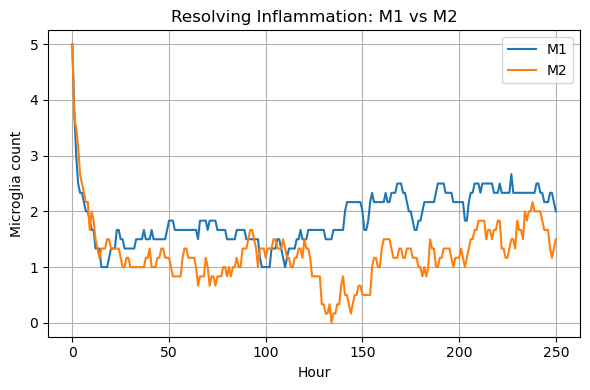

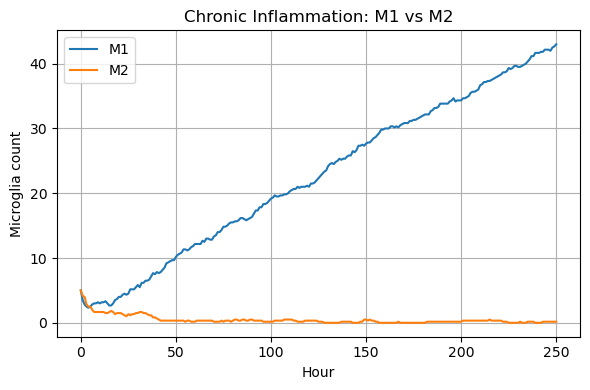

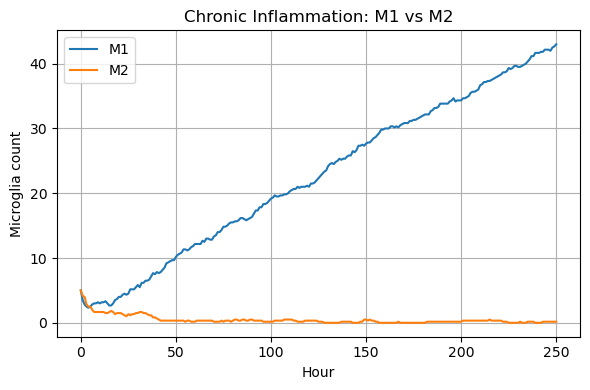

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Helpers
# ============================================================
def run_model_df(params, steps=250, seed=0):
    """Run one ABM simulation and return model_vars DataFrame with an Hour column."""
    p = dict(params)
    p["seed"] = seed

    model = MicrogliaNeuronModel(**p)
    for _ in range(steps):
        model.step()

    df = model.datacollector.get_model_vars_dataframe().reset_index(drop=True)
    df["Hour"] = np.arange(len(df))

    # sanitize
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return df

def run_many(params, steps=250, n_runs=6, seed0=0):
    """Run multiple replicates and stack into one long DataFrame."""
    return pd.concat(
        [run_model_df(params, steps=steps, seed=seed0 + i).assign(Run=i) for i in range(n_runs)],
        ignore_index=True
    )

def mean_over_runs(df, cols):
    """Average selected columns over runs at each Hour."""
    out = df.groupby("Hour", as_index=False)[cols].mean()
    return out.replace([np.inf, -np.inf], np.nan).fillna(0.0)

def plot_m1_m2(df_mean, title, outfile):
    """Plot and save M1 vs M2 from an averaged dataframe."""
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(df_mean["Hour"], df_mean["microglia_M1"], label="M1")
    ax.plot(df_mean["Hour"], df_mean["microglia_M2"], label="M2")
    ax.set_title(title)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Microglia count")
    ax.legend()
    ax.grid(True)
    fig.tight_layout()
    fig.savefig(outfile, bbox_inches="tight")
    plt.show()
    return fig

# ============================================================
# Parameters
# ============================================================
base = dict(
    width=33, height=33, torus=True,
    init_m0_microglia=5, init_m1_microglia=5, init_m2_microglia=5,
    init_healthy_neuron=40, init_damaged_neuron=8, init_dead_neuron=2,
    init_a0_astrocytes=10, init_a1_astrocytes=5, init_a2_astrocytes=5,
)

params_resolving = dict(base, **dict(
    pro_decay=0.20,
    anti_decay=0.10,
    microglia_ld_pro_inflam_threshold=5.0,
    microglia_ld_pro_inflam_boost=0.5,
))

params_chronic = dict(base, **dict(
    pro_decay=0.02,
    anti_decay=0.01,
    microglia_ld_pro_inflam_threshold=1.0,
    microglia_ld_pro_inflam_boost=1.5,
    # optional knobs:
    # microglia_recruitment_prob=0.10,
    # astro_ld_oxidation_rate=0.0,
))

# ============================================================
# Run + Average
# ============================================================
STEPS = 250
N_RUNS = 6

dfR = run_many(params_resolving, steps=STEPS, n_runs=N_RUNS, seed0=100)
dfC = run_many(params_chronic,   steps=STEPS, n_runs=N_RUNS, seed0=200)

cols = ["microglia_M1", "microglia_M2"]
R = mean_over_runs(dfR, cols)
C = mean_over_runs(dfC, cols)

# ============================================================
# Figures (only the final saved ones)
# ============================================================
plot_m1_m2(R, "Resolving Inflammation: M1 vs M2", "figure_M1_M2_resolving.pdf")
plot_m1_m2(C, "Chronic Inflammation: M1 vs M2",   "figure_M1_M2_chronic.pdf")


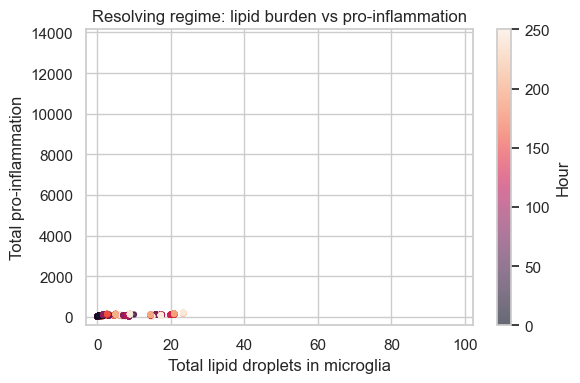

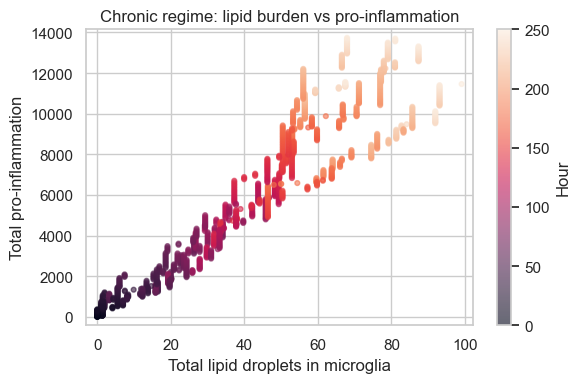

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure seaborn style is set (this affects the colormap)
sns.set(style="whitegrid")

# --- global limits across BOTH regimes ---
x_min = min(dfR["total_ld_microglia"].min(), dfC["total_ld_microglia"].min())
x_max = max(dfR["total_ld_microglia"].max(), dfC["total_ld_microglia"].max())

y_min = min(dfR["total_pro_inflammation"].min(), dfC["total_pro_inflammation"].min())
y_max = max(dfR["total_pro_inflammation"].max(), dfC["total_pro_inflammation"].max())

t_min = min(dfR["Hour"].min(), dfC["Hour"].min())
t_max = max(dfR["Hour"].max(), dfC["Hour"].max())

# small padding so points aren't on the border
pad_x = 0.03 * (x_max - x_min + 1e-9)
pad_y = 0.03 * (y_max - y_min + 1e-9)

xlim = (x_min - pad_x, x_max + pad_x)
ylim = (y_min - pad_y, y_max + pad_y)

def scatter_timecolored_same_scale(df, title, outname_pdf):
    fig, ax = plt.subplots(figsize=(6,4))
    sc = ax.scatter(
        df["total_ld_microglia"],
        df["total_pro_inflammation"],
        c=df["Hour"],
        s=12,
        alpha=0.6,
        vmin=t_min, vmax=t_max,   # SAME color scale
    )
    ax.set_xlim(*xlim)           # SAME x scale
    ax.set_ylim(*ylim)           # SAME y scale
    ax.set_xlabel("Total lipid droplets in microglia")
    ax.set_ylabel("Total pro-inflammation")
    ax.set_title(title)
    ax.grid(True)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Hour")

    fig.tight_layout()
    fig.savefig(outname_pdf, bbox_inches="tight")
    plt.show()

scatter_timecolored_same_scale(
    dfR,
    "Resolving regime: lipid burden vs pro-inflammation",
    "figure_lipid_vs_proinflam_resolving_same_scale.pdf",
)

scatter_timecolored_same_scale(
    dfC,
    "Chronic regime: lipid burden vs pro-inflammation",
    "figure_lipid_vs_proinflam_chronic_same_scale.pdf",
)

## References

- Angiari, S., D'Alessandro, G., Paolicelli, R. C., Prada, I., & Vannini, E. (2022). Cell-cell interactions controlling neuronal functionality in health and disease. Frontiers in Integrative Neuroscience, 16, 968029.

- Nickaeen, N., Ghaisari, J., Heiner, M., Moein, S., & Gheisari, Y. (2019). Agent-based modeling and bifurcation analysis reveal mechanisms of macrophage polarization and phenotype pattern distribution. Scientific reports, 9(1), 12764.

- Ty, C., Case, A., Mezzulo, E., Penland, A., & Larripa, K. (2025). An Agent-Based Model of Microglia and Neuron Interaction: Implications in Neurodegenerative Disease. Spora: A Journal of Biomathematics, 11(1), 20-35.


## Acknowledgments
This work is supported by the National Science Foundation through the Mathematical Biology Program and the Systems and Synthetic Biology Cluster.  We are extremely grateful for this support.  (Award 2245839)
